<a href="https://colab.research.google.com/github/daniel2255555/Ai-Assignment/blob/main/TraditionalMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Cell 1: Install dependencies
!pip install opencv-python-headless scikit-learn scikit-image matplotlib seaborn joblib kaggle

# Cell 2: Download FER2013 from Kaggle
# Upload your kaggle.json first, then:
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d msambare/fer2013
!unzip fer2013.zip -d fer2013/

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__del__'
Traceback (most recent call last):
  File "_zmq.py", line 160, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
fer2013.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  fer2013.zip
replace fer2013/test/angry/PrivateTest_10131363.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [18]:
import os, cv2, numpy as np
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler, LabelEncoder

EMOTIONS = ['angry','disgust','fear','happy','neutral','sad','surprise']
DATA_DIR = 'fer2013/train'

def extract_hog(img_gray):
    """Extract HOG features — the SVM's eyes."""
    features, _ = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        visualize=True,
        block_norm='L2-Hys'
    )
    return features

X, y = [], []
for label in EMOTIONS:
    folder = os.path.join(DATA_DIR, label)
    for fname in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (48, 48))
            X.append(extract_hog(img))
            y.append(label)

X = np.array(X)
y = np.array(y)
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features each")

Dataset: 28709 samples, 4356 features each


Variance retained: 95.0%
LinearSVC report:
              precision    recall  f1-score   support

       angry       0.28      0.28      0.28       200
     disgust       0.55      0.12      0.20        88
        fear       0.23      0.14      0.18       200
       happy       0.37      0.55      0.44       200
     neutral       0.30      0.30      0.30       200
         sad       0.24      0.15      0.19       200
    surprise       0.37      0.58      0.46       200

    accuracy                           0.32      1288
   macro avg       0.34      0.31      0.29      1288
weighted avg       0.32      0.32      0.30      1288

Fitting 3 folds for each of 9 candidates, totalling 27 fits
GridSearchCV best parameters:
{'C': 5, 'gamma': 0.001}
RBF SVM report (with best parameters from GridSearchCV):
              precision    recall  f1-score   support

       angry       0.27      0.36      0.31       200
     disgust       0.92      0.26      0.41        88
        fear       0.25  

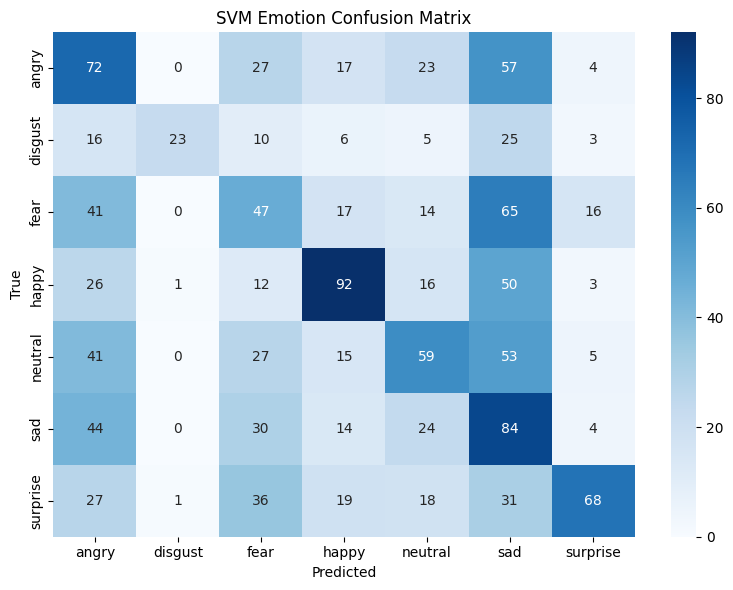

['emotion_pca.pkl']

In [22]:
import os, cv2, numpy as np
from skimage.feature import hog, local_binary_pattern
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib # Import joblib to save models

# Define feature extraction function (HOG + LBP)
def extract_features(img_gray):
    hog_feats, _ = hog(img_gray, orientations=9, pixels_per_cell=(4,4),
                       cells_per_block=(2,2), visualize=True, block_norm='L2-Hys')
    lbp = local_binary_pattern(img_gray, P=8, R=1, method='uniform')
    # LBP histogram with 10 bins, range 0-10, as there are 10 possible uniform patterns for P=8, R=1
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
    return np.concatenate([hog_feats, lbp_hist])

EMOTIONS = ['angry','disgust','fear','happy','neutral','sad','surprise']
DATA_DIR = 'fer2013/train'

X, y = [], []
for label in EMOTIONS:
    folder = os.path.join(DATA_DIR, label)
    for fname in os.listdir(folder)[:1000]:  # limit for speed
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (48, 48))
            X.append(extract_features(img)) # Use the combined HOG+LBP features
            y.append(label)

X = np.array(X)
y = np.array(y)

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ---- OPTIMIZATION 1: PCA to shrink feature dimensions ----
pca = PCA(n_components=0.95, whiten=True, random_state=42)  # keep 95% variance
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca  = pca.transform(X_test_s)
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.1%}")

# ---- OPTIMIZATION 2: Use LinearSVC first (100x faster than RBF) ----
linear_svc = CalibratedClassifierCV(LinearSVC(C=0.1, max_iter=2000, random_state=42)) # Added random_state for reproducibility
linear_svc.fit(X_train_pca, y_train)
y_pred_linear = linear_svc.predict(X_test_pca)
print("LinearSVC report:")
print(classification_report(y_test, y_pred_linear, target_names=le.classes_))

# ---- OPTIMIZATION 3: RBF only on PCA-reduced features with GridSearchCV ----
# Perform GridSearchCV for optimal RBF SVM parameters
params = {'C': [1, 5, 10], 'gamma': ['scale', 0.01, 0.001]}
grid = GridSearchCV(SVC(kernel='rbf', probability=True, cache_size=500, random_state=42), # Added random_state
                    params, cv=3, n_jobs=-1, verbose=1) # Added verbose for progress
grid.fit(X_train_pca, y_train)

print("GridSearchCV best parameters:")
print(grid.best_params_)

# Use the best estimator found by GridSearchCV
svm = grid.best_estimator_
y_pred = svm.predict(X_test_pca)
print("RBF SVM report (with best parameters from GridSearchCV):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('SVM Emotion Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

# Save the trained model, scaler, and label encoder
joblib.dump(svm, 'emotion_svm.pkl')
joblib.dump(scaler, 'emotion_scaler.pkl')
joblib.dump(le, 'emotion_le.pkl')
joblib.dump(pca, 'emotion_pca.pkl') # Save the PCA object as well

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once Google Drive is mounted, you can copy the model files to a desired location. For example, to a folder named `emotion_model` in your Drive, run the following code. You can change `emotion_model` to any folder name you prefer.

In [30]:
import os
import shutil

# Define the target directory in Google Drive
drive_path = '/content/drive/My Drive/emotion_model'

# Create the directory if it doesn't exist
os.makedirs(drive_path, exist_ok=True)

# List of model files to save
model_files = ['emotion_svm.pkl', 'emotion_scaler.pkl', 'emotion_le.pkl', 'emotion_pca.pkl']

# Copy each file to Google Drive
for filename in model_files:
    source_path = os.path.join('/content', filename)
    destination_path = os.path.join(drive_path, filename)
    if os.path.exists(source_path):
        shutil.copy(source_path, destination_path)
        print(f'Copied {filename} to {destination_path}')
    else:
        print(f'File not found: {filename}')

print(f"All specified model files have been copied to {drive_path}")

Copied emotion_svm.pkl to /content/drive/My Drive/emotion_model/emotion_svm.pkl
Copied emotion_scaler.pkl to /content/drive/My Drive/emotion_model/emotion_scaler.pkl
Copied emotion_le.pkl to /content/drive/My Drive/emotion_model/emotion_le.pkl
Copied emotion_pca.pkl to /content/drive/My Drive/emotion_model/emotion_pca.pkl
All specified model files have been copied to /content/drive/My Drive/emotion_model


In [25]:
# Cell: Webcam capture helper (run ONCE in Colab)
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL.Image, io

def take_photo(quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = '📷 Capture';
          div.appendChild(capture);
          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();
          await new Promise((r) => capture.onclick = r);
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getTracks().forEach(t => t.stop());
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
        takePhoto(%f)
    ''' % quality)
    display(js)
    data = eval_js('takePhoto(%f)' % quality)
    binary = b64decode(data.split(',')[1])
    return PIL.Image.open(io.BytesIO(binary))

<IPython.core.display.Javascript object>

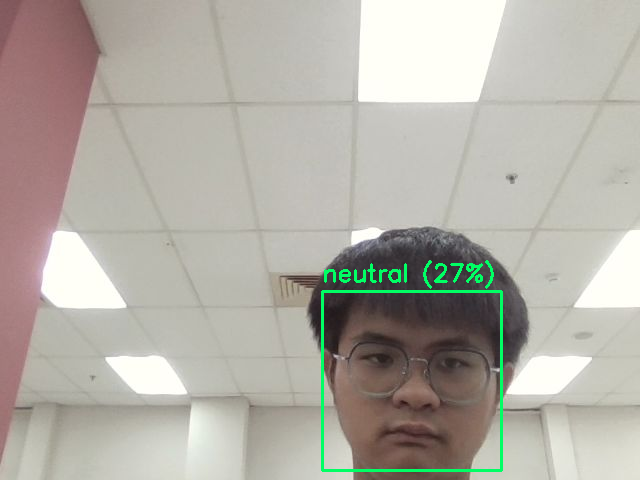

In [29]:
import numpy as np, cv2
from skimage.feature import hog, local_binary_pattern # Import local_binary_pattern
import joblib # Import joblib

# Load saved model
svm    = joblib.load('emotion_svm.pkl')
scaler = joblib.load('emotion_scaler.pkl')
le     = joblib.load('emotion_le.pkl')
pca    = joblib.load('emotion_pca.pkl') # Load the PCA object

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Define the same feature extraction function as used during training
def extract_features(img_gray):
    hog_feats, _ = hog(img_gray, orientations=9, pixels_per_cell=(4,4),
                       cells_per_block=(2,2), visualize=True, block_norm='L2-Hys')
    lbp = local_binary_pattern(img_gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
    return np.concatenate([hog_feats, lbp_hist])

def predict_emotion(pil_img):
    img = np.array(pil_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))

    for (x, y, w, h) in faces:
        roi = gray[y:y+h, x:x+w]
        roi = cv2.resize(roi, (48, 48))
        # Use the combined feature extraction function
        feats = extract_features(roi).reshape(1,-1)
        feats_s = scaler.transform(feats)
        feats_pca = pca.transform(feats_s) # Apply PCA transformation
        label = le.inverse_transform(svm.predict(feats_pca))[0]
        prob   = svm.predict_proba(feats_pca).max()

        # Draw bounding box and label
        cv2.rectangle(img, (x,y), (x+w, y+h), (0,255,100), 2)
        cv2.putText(img, f"{label} ({prob:.0%})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,100), 2)

    return PIL.Image.fromarray(img)

# Capture & predict
photo = take_photo()
result = predict_emotion(photo)
display(result)